In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [2]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
FEATURES_TO_CONSIDER = [0, 1, 15, 16]

Z_DIM = 128
TRAJECTORY_NUM_ANCHORS = 200


In [3]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [4]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/wrappers/monitoring/video_recorder.py:9: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn
/home/nazim/.local/lib/python3.10/site-packages/mujoco_py/builder.py:9: DeprecationWarning: The distutils.sysconfig module is deprecated, use sysconfig instead
  from distutils.sysconfig import customize_compiler
<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead
No module named 'flow'
No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.08822022776461, 25.377647120464115)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.55it/s]


In [5]:
x = dataset['observations']
coord_0_min, coord_0_max, coord_1_min, coord_1_max = x[:, 0].min(), x[:, 0].max(), x[:, 1].min(), x[:, 1].max()


def normalize_dataset_coords(dataset_):
    dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
    dataset[..., 0] = ((dataset[..., 0] - coord_0_min) / (coord_0_max - coord_0_min) - 0.5) * 20
    dataset[..., 1] = ((dataset[..., 1] - coord_1_min) / (coord_1_max - coord_1_min) - 0.5) * 20
    return dataset

def denormalize_dataset_coords(dataset_):
    dataset = dataset_.clone() if isinstance(dataset_, torch.Tensor) else dataset_.copy()
    dataset[..., 0] = ((dataset[..., 0] / 20) + 0.5) * (coord_0_max - coord_0_min) + coord_0_min
    dataset[..., 1] = ((dataset[..., 1] / 20) + 0.5) * (coord_1_max - coord_1_min) + coord_1_min
    return dataset

In [6]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])
dataset_goals = normalize_dataset_coords(dataset_goals)



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)



num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [7]:
class RNDModule(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self):
        self.current = RNDModule().to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule().to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x, batch_size=1024, alpha=1.):
        
        w_list = []
        x = x.to(device)
        with torch.no_grad():
            for i in range(0, x.size(0), batch_size):
                x_batch = x[i:i+batch_size]
                yc = self.current(x_batch)
                yt = self.target(x_batch)
                w_batch = (yc - yt).pow(2).sum(-1).cpu()
                w_list.append(w_batch)
        w = torch.cat(w_list, dim=0)

        w = w ** alpha
        w = w / w.sum()

        return w
    
    
    

resampler = RNDResampling()
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
resampler_losses = resampler.fit(rnd_dataset, epochs=5000)
resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=1.)
resampling_weights = resampling_weights
trajectories_weights = resampling_weights.reshape(-1, TRAJECTORY_LEN).sum(dim=1)

100%|██████████| 5000/5000 [00:03<00:00, 1660.21it/s]


# Trajectory encoder:

In [8]:

class RNDModule(nn.Module):
    def __init__(self, ):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
        )
        
    def forward(self, x):
        return self.model(x)

class RNDResampling:
    def __init__(self):
        self.current = RNDModule().to(device)
        self.current_optimizer = torch.optim.SGD(self.current.parameters())
        self.target = RNDModule().to(device)
        self.target.requires_grad_ = False
        self.rnd_losses = []


    def fit(self, dataset, epochs=1000, batch_size=16):

        for _ in tqdm(range(epochs)):
        
            x = dataset[torch.randint(0, dataset.shape[0], (batch_size,))]
            x = x.to(device)

            yc = self.current(x)
            with torch.no_grad():
                yt = self.target(x)

            loss = (yc - yt).pow(2).sum(-1).mean()

            self.current_optimizer.zero_grad()
            loss.backward()
            self.current_optimizer.step()
            
            self.rnd_losses.append(loss.item())
        
        return self.rnd_losses
    
    
    def get_resampling_weights(self, x, batch_size=1024, alpha=1.):
        
        w_list = []
        x = x.to(device)
        with torch.no_grad():
            for i in range(0, x.size(0), batch_size):
                x_batch = x[i:i+batch_size]
                yc = self.current(x_batch)
                yt = self.target(x_batch)
                w_batch = (yc - yt).pow(2).sum(-1).cpu()
                w_list.append(w_batch)
        w = torch.cat(w_list, dim=0)

        w = w ** alpha
        w = w / w.sum()

        return w

In [9]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [10]:
class FRENetwork(nn.Module):
    def __init__(self, state_dim, action_dim, num_heads=2, num_layers=2, d_model=128):
        super().__init__()
        
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.d_model = d_model
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.d_model, 
                num_heads, 
                dim_feedforward=4*self.d_model, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.d_model, self.d_model)
        self.encoder_log_std = nn.Linear(self.d_model, self.d_model)

        self.state_embed = nn.Linear(self.state_dim, self.d_model // 2)
        self.action_embed = nn.Linear(self.action_dim, self.d_model // 2)

        self.action_predict = nn.Sequential(
            nn.Linear(self.state_dim + self.d_model, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, action_dim),
            nn.Tanh()
        )
        
        self.init_std = 0.25
        self.log_std = nn.Parameter(torch.ones(action_dim) * self.init_std)
        
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=0.1, max_len=200)



    def get_transformer_encoding(self, states, actions, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=states.device)
        # pad_mask.shape = [batch, anchors]
                
        state_emb = self.state_embed(states)
        action_emb = self.action_embed(actions)
        
        state_action_emb = torch.concat([state_emb, action_emb], dim=-1)
        
        x = self.positional_encoding(state_action_emb)
        w_pre = self.encoder_transformer(x, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_action_pred(self, w, states): # Reward Pairs: [batch, seq, obs_dim]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, states], axis=-1)
        
        mean = self.action_predict(w_and_obs)
        log_std = torch.clip(self.log_std, -20, 2)
        
        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)
        )        

In [52]:
def iou_similarity(traj1, traj2, grid_size=2):
    traj1 = (np.array(traj1[..., :2]) / grid_size).astype(int)
    traj2 = (np.array(traj2[..., :2]) / grid_size).astype(int)
    
    set1 = set(map(tuple, traj1))
    set2 = set(map(tuple, traj2))

    intersection = len(set1 & set2)
    union = len(set1 | set2)

    return intersection / union if union > 0 else 0.0

In [53]:
trajectories_near_trajectories_indicices = []
for trajectory_idx in tqdm(dataset_trajectories.shape[0]):
    t = dataset_trajectories[trajectory_idx, ::100, :2]
    x = dataset_trajectories[:, ::100, :2]
    sims = torch.tensor([iou_similarity(t, x[i]) for i in range(x.shape[0])])
    near_trajectories_indicices = torch.nonzero(sims > 0.5).flatten()
    trajectories_near_trajectories_indicices.append(near_trajectories_indicices.tolist())

100%|█████████▉| 999/1000 [00:21<00:00, 45.70it/s]


IndexError: index 999 is out of bounds for dimension 0 with size 999

In [80]:
def trajectory_value_function(states, target_trajectory):
    assert target_trajectory.dim() == 2 # (num_anchors, obs_dim)
    assert states.dim() == 2     # (num_states, obs_dim)
    
    
    distances = (states[:, None] - target_trajectory[None, :]).pow(2).sum(dim=-1)
        
    min_info = distances.min(dim=-1)
    min_distances, clostest_anchor = min_info.values, min_info.indices

    # return clostest_anchor[:states.shape[0]]
    
    r = (min_distances < 1000) * clostest_anchor
    # r = clostest_anchor
    
    return r



def trajectory_value_function_2(states, next_states, target_trajectory):
    assert target_trajectory.dim() == 2 # (num_anchors, obs_dim)
    assert states.dim() == 2     # (num_states, obs_dim)
    
    
    states = states.to(device)
    next_states = next_states.to(device)
    target_trajectory = target_trajectory.to(device)
    
    states_distances = (states[:, None] - target_trajectory[None, :]).pow(2).sum(dim=-1)
    states_min_info = states_distances.sort(dim=-1)
    states_min_distances_1st, states_clostest_anchor_1st = states_min_info.values[:, 0], states_min_info.indices[:, 0]
    
    next_states_distances = (next_states[:, None] - target_trajectory[None, :]).pow(2).sum(dim=-1)
    next_states_min_info = next_states_distances.sort(dim=-1)
    next_states_min_distances_1st, next_states_clostest_anchor_1st = next_states_min_info.values[:, 0], next_states_min_info.indices[:, 0]

    
    v_states = states_clostest_anchor_1st
    v_next_states = next_states_clostest_anchor_1st
    
    next_anchor_index = torch.minimum(states_clostest_anchor_1st+1, torch.tensor(target_trajectory.shape[1]-1, device=device))
    rows_arange = torch.arange(0, next_states_distances.shape[0], device=device)
    
    distance_between_next_state_and_next_anchor = next_states_distances[rows_arange, next_anchor_index]
    distance_between_state_and_next_anchor = states_distances[rows_arange, next_anchor_index]
    
    # If the next state is ahead, even if they have the same closest anchor, the next value should be bigger to encourage the agent forward:
    
    # same_state = (v_states == v_next_states)
    # closer_to_next_anchor = (distance_between_next_state_and_next_anchor <= distance_between_state_and_next_anchor)
    # v_next_states = torch.where(
    #     same_state,
    #     torch.where(closer_to_next_anchor, v_next_states + 0.2, v_next_states - 0.2),
    #     v_next_states
    # )
    
    return v_states.cpu(), v_next_states.cpu()


def get_importance_sampling_indices(N, weights):
    # print(N, weights.shape)
    # if N < weights.shape[0]:
    indices = torch.multinomial(weights, N, replacement=(N >= weights.shape[0]))
    return indices



def iou_similarity_torch(traj1, traj2, grid_size=2):
    # Ensure tensors are on the same device
    device = traj1.device
    traj1 = (traj1[..., :2] / grid_size).floor().int()
    traj2 = (traj2[..., :2] / grid_size).floor().int()

    # Create unique 1D indices by hashing the 2D coordinates
    max_val = 100000  # Assumes coordinates after scaling are < max_val
    hash1 = traj1[:, 0] * max_val + traj1[:, 1]
    hash2 = traj2[:, 0] * max_val + traj2[:, 1]

    # Remove duplicates
    unique1 = torch.unique(hash1)
    unique2 = torch.unique(hash2)

    # Compute intersection and union
    intersection = torch.isin(unique1, unique2).sum()
    union = torch.unique(torch.cat([unique1, unique2])).numel()

    res = intersection.float() / union if union > 0 else torch.tensor(0.0, device=device)
    return res.item()


def get_iql_training_data(batch_size, num_states, num_trajectory_states, trajectory_indicies:torch.Tensor=None):

    # batch_size = 16
    # num_trajectory_states = 200
    # num_states = 1024

    # trajectory_indicies = trajectory_encoder.get_importance_sampling_indices(batch_size, trajectory_encoder.trajectories_weights)
    
    if trajectory_indicies is None:
        trajectory_indicies = torch.randint(0, dataset_trajectories.shape[0], (batch_size,))
    else:
        batch_size = trajectory_indicies.shape[0]
    


    states = torch.zeros((batch_size, num_states, obs_dim))
    next_states = torch.zeros((batch_size, num_states, obs_dim))
    actions = torch.zeros((batch_size, num_states, 8))
    masks = torch.zeros((batch_size, num_states, 1))
    rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    next_values = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    values = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    
    traj_anchors = torch.zeros((batch_size, num_trajectory_states, obs_dim))
    traj_anchors_actions = torch.zeros((batch_size, num_trajectory_states, 8))
    
    target_trajectories = torch.zeros((batch_size, dataset_trajectories.shape[1], obs_dim))
    target_actions = torch.zeros((batch_size, dataset_trajectories.shape[1], 8))



    for i, trajectory_idx in enumerate(trajectory_indicies):

        target_trajectory = dataset_trajectories[trajectory_idx, :, :]
        target_action = dataset_actions[trajectory_idx, :, :]

        # t = dataset_trajectories[trajectory_idx, ::100, :2].to(device)
        # x = dataset_trajectories[:, ::100, :2].reshape(-1, 2).to(device)
        # distance_to_trajectory = (x[:, None] - t[None]).pow(2).sum(-1).reshape(dataset_trajectories.shape[0], -1, t.shape[0]).min(dim=-1).values.sum(dim=-1)
        # distance_to_trajectory = distance_to_trajectory.cpu()
        # near_trajectories_indicices = torch.nonzero(distance_to_trajectory < 10).flatten()
        
        # t = dataset_trajectories[trajectory_idx, ::100, :2]
        # x = dataset_trajectories[:, ::100, :2]
        # sims = torch.tensor([iou_similarity(t, x[i]) for i in range(x.shape[0])])
        # near_trajectories_indicices = torch.nonzero(sims > 0.5).flatten()
        
        near_trajectories_indicices = torch.tensor(trajectories_near_trajectories_indicices[trajectory_idx])
        
        # plt.hist(sims.cpu(), bins=100)
        # plt.show()
        # print(near_trajectories_indicices)
        
        # print(near_trajectories_indicices)
        # print(len(near_trajectories_indicices))
        
        near_trajectories = dataset_trajectories[near_trajectories_indicices]

        ti = torch.randint(0, near_trajectories.shape[0], (num_states,))
        si = torch.randint(0, near_trajectories.shape[1]-1, (num_states,))
        
        # si = get_importance_sampling_indices(num_states, resampling_weights.reshape(999, 1001)[near_trajectories_indicices].flatten())
        # ti, si = si // 1001, si % 1000
        ti = near_trajectories_indicices[ti]
        
        
        states[i] = dataset_trajectories[ti, si]
        next_states[i] = dataset_trajectories[ti, si+1]
        actions[i] = dataset_actions[ti, si]
        masks[i] = ~dataset_timeouts[ti, si+1].unsqueeze(-1)
        
        traj_anchors[i] = target_trajectory[torch.linspace(0, target_trajectory.shape[0]-1, num_trajectory_states, dtype=torch.long)]
        traj_anchors_actions[i] = target_action[torch.linspace(0, target_action.shape[0]-1, num_trajectory_states, dtype=torch.long)]
        
        # rewards[i] = trajectory_reward_function(states[i, :, :2], next_states[i, :, :2], target_trajectory[:, :2]).unsqueeze(-1)
        # values[i] = trajectory_value_function(states[i, :, :2], target_trajectory[:, :2]).unsqueeze(-1)
        # next_values[i] = trajectory_value_function(next_states[i, :, :2], target_trajectory[:, :2]).unsqueeze(-1)
        
        values_, next_values_ = trajectory_value_function_2(states[i, :, :2], next_states[i, :, :2], target_trajectory[:, :2])
        values[i], next_values[i] = values_.unsqueeze(-1), next_values_.unsqueeze(-1)
        
        target_trajectories[i] = dataset_trajectories[trajectory_idx]
        target_actions[i] = dataset_actions[trajectory_idx]

    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'rewards': rewards.to(device),
        'masks': masks.to(device),
        'values': values.to(device),
        'next_values': next_values.to(device),
        
        'traj_anchors': traj_anchors.to(device),
        'traj_anchors_actions': traj_anchors_actions.to(device),
        
        'target_trajectories': target_trajectories.to(device),
        'target_actions': target_actions.to(device),
    }

In [81]:
def get_training_data_0(batch_size, num_states, num_trajectory_states, trajectories_idx_=None):
    
    num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape
    
    if trajectories_idx_ is not None:
        batch_size = len(trajectories_idx_)
        
    if trajectories_idx_ is None: 
        trajectories_idx_ = torch.randint(0, num_trajectories, (batch_size,))      
        
    trajectories_idx_ = trajectories_idx_.unsqueeze(-1).long()    
    
    
    trajectories_idx = trajectories_idx_.repeat(1, num_trajectory_states).reshape(-1)
    states_idx = torch.linspace(0, len_trajectory-1, num_trajectory_states).long().repeat(batch_size)
    anchors = dataset_trajectories[trajectories_idx, states_idx].reshape(batch_size, num_trajectory_states, -1)
    anchors_actions = dataset_actions[trajectories_idx, states_idx].reshape(batch_size, num_trajectory_states, -1)
    
    
    trajectories_idx = trajectories_idx_.repeat(1, num_states).reshape(-1)
    states_idx = torch.linspace(0, len_trajectory-2, num_states).long().repeat(batch_size)
    states = dataset_trajectories[trajectories_idx, states_idx].reshape(batch_size, num_states, -1)
    next_states = dataset_trajectories[trajectories_idx, states_idx+1].reshape(batch_size, num_states, -1)
    actions = dataset_actions[trajectories_idx, states_idx].reshape(batch_size, num_states, -1)
    
    
    
    next_values = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    values = torch.zeros((batch_size, num_states, 1), dtype=torch.float)
    target_trajectories = torch.zeros((batch_size, dataset_trajectories.shape[1], obs_dim))
    target_actions = torch.zeros((batch_size, dataset_trajectories.shape[1], 8))
    
    # for i, trajectory_idx in enumerate(trajectories_idx_.flatten()):
        
    #     target_trajectories[i] = dataset_trajectories[trajectory_idx]
    #     target_actions[i] = dataset_actions[trajectory_idx]
        
    #     target_trajectory = dataset_trajectories[trajectory_idx, :, :]
    #     values[i] = trajectory_value_function(states[i, :, :2], target_trajectory[:, :2]).unsqueeze(-1)
    #     next_values[i] = trajectory_value_function(next_states[i, :, :2], target_trajectory[:, :2]).unsqueeze(-1)
    
    # return (anchors, anchors_actions), (states, actions), {'trajectories_idx': trajectories_idx_}

    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        # 'rewards': rewards.to(device),
        # 'masks': masks.to(device),
        'values': values.to(device),
        'next_values': next_values.to(device),
        
        'traj_anchors': anchors.to(device), 
        'traj_anchors_actions': anchors_actions.to(device),
        
        # 'target_trajectories': target_trajectories.to(device),
        # 'target_actions': target_actions.to(device),
    }

In [96]:
# batch = get_iql_training_data(batch_size=1, num_states=10000, num_trajectory_states=200, trajectory_indicies=torch.tensor([7]))
# # batch = get_training_data_0(batch_size=1, num_states=1000, num_trajectory_states=200)


# # plt.figure(figsize=(10, 8))
# plt.scatter(dataset_trajectories[:, ::10, 0],    dataset_trajectories[:, ::10, 1], c='gray')

# i = 0
# plt.scatter(batch['states'][i, :, 0].cpu(), batch['states'][i, :, 1].cpu(), c=(batch['next_values'] - batch['values'])[i, :, 0].cpu(), s=1, vmin=-1, vmax=1)

# plt.scatter(batch['traj_anchors'][i, :, 0].cpu(), batch['traj_anchors'][i, :, 1].cpu(), c='red', s=1)


In [97]:
# batch = get_iql_training_data(batch_size=1, num_states=2024, num_trajectory_states=200)
# # batch = get_training_data_0(batch_size=1, num_states=1000, num_trajectory_states=200)

# plt.figure(figsize=(10, 8))

# plt.scatter(dataset_trajectories[:, ::10, 0],    dataset_trajectories[:, ::10, 1], c='gray')

# i = 0
# # plt.scatter(batch['states'][i, :, 0].cpu(), batch['states'][i, :, 1].cpu(), c=(batch['next_values'] - batch['values'])[i, :, 0].cpu(), s=1, vmin=-1, vmax=1)
# plt.scatter(batch['states'][i, :, 0].cpu(), batch['states'][i, :, 1].cpu(), c=batch['values'][i, :, 0].cpu(), s=1)
# plt.scatter(batch['traj_anchors'][i, :, 0].cpu(), batch['traj_anchors'][i, :, 1].cpu(), c='red', s=1)


# for i in range(0, 2024, 1):
#     if (batch['next_values'] - batch['values'])[0, i, 0] == 1:
#         x, y = batch['states'][0, i, 0], batch['states'][0, i, 1]
#         dx, dy = batch['next_states'][0, i, 0] - batch['states'][0, i, 0], batch['next_states'][0, i, 1] - batch['states'][0, i, 1]
#         x, y, dx, dy = x.cpu(), y.cpu(), dx.cpu(), dy.cpu()
#         plt.arrow(x, y, dx * 5, dy * 5, head_width=0.2)


---

In [98]:
frenetwork = FRENetwork(state_dim=obs_dim, action_dim=8, num_layers=2, num_heads=2).to(device)
# frenetwork.load_state_dict(torch.load('models/vae_optimal_v_frenetwork_2.pth'))

optimimizer = torch.optim.Adam(frenetwork.parameters(), lr=0.001)

losses = []
kl_losses = []

/tmp/ipykernel_14231/1515834542.py:58: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[0].set_xscale('log')


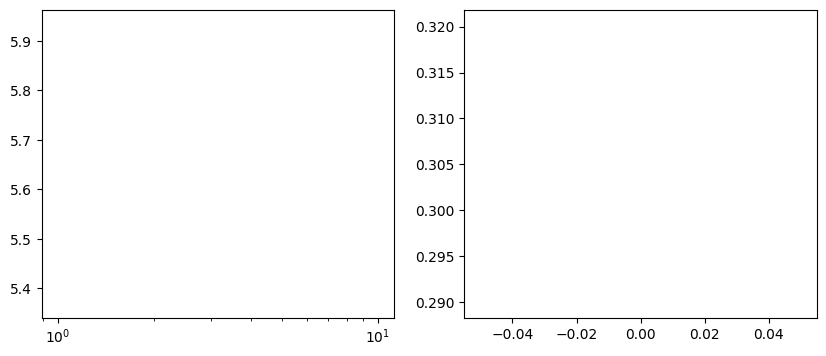

  0%|          | 11/10000 [00:04<1:09:11,  2.41it/s]


KeyboardInterrupt: 

In [99]:
batch_size = 16

for i in tqdm(range(10000)):
    # (anchors, anchor_actions), (states, actions), info = get_training_data(
    #     batch_size=128,
    #     num_anchors=200,
    #     num_states=1000
    # )
    
    batch = get_iql_training_data(batch_size=batch_size, num_states=10240, num_trajectory_states=200)
    # batch = get_training_data_0(batch_size=batch_size, num_states=1001, num_trajectory_states=200)

    
    w_mean, w_log_std = frenetwork.get_transformer_encoding(batch['traj_anchors'], batch['traj_anchors_actions'], pad_mask=None)


    # all_states = torch.concat((batch['states'], batch['target_trajectories']), dim=1)
    # all_actions = torch.concat((batch['actions'], batch['target_actions']), dim=1)
    all_states = batch['states']
    all_actions = batch['actions']
    # exp_a = (batch['next_values'] - batch['values']).clip(0, 5)
    # exp_a = torch.concat((exp_a, torch.ones((batch_size, 1001, 1), device=device)), dim=1).squeeze(-1)

    dist = frenetwork.get_action_pred(w_mean, all_states)
    # log_probs = dist.log_prob(all_actions).sum(axis=-1, keepdim=True)
    
    # assert exp_a.shape == log_probs.shape
    # actor_loss = -(exp_a * log_probs).mean()
    
    actor_loss = (dist.loc - all_actions).pow(2).sum(-1).mean()
    # actor_loss = exp_a[..., None] * (dist.loc - all_actions).pow(2)
    # actor_loss = actor_loss.sum() / (exp_a != 0).sum()
    # actor_loss = actor_loss.mean()


    kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
    loss = actor_loss + kl_loss * 0.01
            
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()

    logs = {
        'loss': loss.item(),
        'actor_loss': actor_loss.item(),
        'kl_loss': kl_loss.item(),
    }
    
    losses.append(logs['actor_loss'])
    kl_losses.append(logs['kl_loss'])
    
    if i % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        # axs[0].plot(smooth_and_downsample(losses))
        axs[0].plot(losses)
        axs[0].set_xscale('log')
        axs[1].plot(kl_losses)
        plt.show()

In [ ]:
# plt.scatter(all_states[..., 0], all_states[..., 1], c=exp_a)

In [ ]:
# torch.save(frenetwork.state_dict(), 'models/vae_optimal_v_frenetwork.pth')
# torch.save(frenetwork.state_dict(), 'models/vae_optimal_v_frenetwork_2.pth')

In [ ]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()



def reset_to_state(env, state):
    env.sim.reset()
    qpos = env.init_qpos
    qpos[:] = np.array(state[:15]).astype(env.observation_space.dtype)
    qvel = env.init_qvel
    qvel[:] = np.array(state[15:]).astype(env.observation_space.dtype)
    
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()



def trajectory_similarity(t1, t2) -> float:

    distances = (((t1[None, :, :2] - t2[:, None, :2]) ** 2).sum(-1) < 2) * 1.

    t1_inter = distances.any(dim=0) * 1.
    t2_inter = distances.any(dim=1) * 1.

    iou = (t1_inter.sum() + t2_inter.sum()) / (t1_inter.numel() + t2_inter.numel())
    
    return min(t1_inter.sum().item(), t2_inter.sum().item()) / t1_inter.numel()

In [ ]:
batch = get_iql_training_data(batch_size=1, num_states=1024, num_trajectory_states=200)

In [ ]:
# batch = get_iql_training_data(
#     batch_size=1, min_trajectory_size=1000, max_trajectory_size=1001, num_anchors_states=200,
#     num_trajectory_states=400, num_random_states=400
# )

# batch = get_iql_training_data(batch_size=1, num_states=512, num_trajectory_states=200)




all_produced_trajectories = []

for _ in range(5):
    
    state = env.reset()
    location = np.array(denormalize_dataset_coords(batch['target_trajectories'][0, 0, :2].cpu()))
    state = reset_to_location(env, location)
    # state = reset_to_state(env, denormalize_dataset_coords(batch['target_trajectories'][0, 0, :].cpu()))
    state = normalize_dataset_coords(state)[..., :STATE_DIM]




    with torch.no_grad():
        w_mean, _ = frenetwork.get_transformer_encoding(batch['traj_anchors'], batch['traj_anchors_actions'], pad_mask=None)
        # w_mean = w_mean.unsqueeze(1)
    
    
    produced_trajectory = []

    for _ in tqdm(range(1001)):
        tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
        
        # print(w_mean.shape, tensor_state.shape)
        
        with torch.no_grad():
            dist = frenetwork.get_action_pred(w_mean, tensor_state)
            pred_action = dist.loc.cpu()
            # pred_action = dist.sample().cpu()
            # print(pred_action.shape)
            action = pred_action[0, 0]
            action = np.array(action)
            
        new_state, _, _, _ = env.step(action)

        
        produced_trajectory.append(state)

        state = new_state
        state = normalize_dataset_coords(state)[..., :STATE_DIM]
        
        
    produced_trajectory = np.stack(produced_trajectory)
    
    all_produced_trajectories.append(produced_trajectory)

all_produced_trajectories = np.array(all_produced_trajectories)

# plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')
# _ = plt.plot(batch['traj_anchors'][..., 0].cpu().flatten(), batch['traj_anchors'][..., 1].cpu().flatten())
# _ = plt.plot(produced_trajectory[..., 0].flatten(), produced_trajectory[..., 1].flatten(), c='red')

Target Goal:  (33.20445648430943, 24.50111925283426)


100%|██████████| 1001/1001 [00:00<00:00, 1071.58it/s]


Target Goal:  (32.703623443714676, 24.808698506840706)


100%|██████████| 1001/1001 [00:00<00:00, 1099.04it/s]


Target Goal:  (33.171111490130656, 24.871854928251818)


100%|██████████| 1001/1001 [00:00<00:00, 1082.26it/s]


Target Goal:  (33.010953034279986, 24.3388298934697)


100%|██████████| 1001/1001 [00:00<00:00, 1094.68it/s]


Target Goal:  (33.369758442089065, 24.527734521644888)


100%|██████████| 1001/1001 [00:00<00:00, 1128.07it/s]


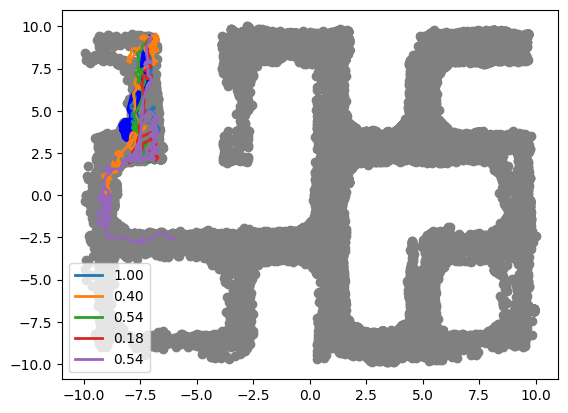

In [ ]:
plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

# _ = plt.scatter(batch['traj_anchors'][..., 0].cpu().flatten(), batch['traj_anchors'][..., 1].cpu().flatten(), s=5, c='blue')
_ = plt.plot(batch['traj_anchors'][..., 0].cpu().flatten(), batch['traj_anchors'][..., 1].cpu().flatten(), linewidth=5, c='blue', alpha=1)

# plt.scatter(produced_trajectory[:, 0], produced_trajectory[:, 1], s=5, c='red')
for i in range(all_produced_trajectories.shape[0]):
    sim = trajectory_similarity(torch.tensor(all_produced_trajectories[i]).cpu(), batch['target_trajectories'][0].cpu()) 
    _ = plt.plot(all_produced_trajectories[i, ..., 0].flatten(), all_produced_trajectories[i, ..., 1].flatten(), linewidth=2, alpha=1, label=f'{sim:.2f}')
plt.legend()

---
# Evaluation:

In [ ]:
NUM_EVALS = 100
NUM_EVAL_SEEDS = 3

In [ ]:
eval_batch = get_iql_training_data(batch_size=1, num_states=512, num_trajectory_states=200, trajectory_indicies=torch.arange(0, NUM_EVALS))

In [ ]:
# all_produced_trajectories = np.load('models/vae_optimal_v_eval_trajectories.npz.npy')

In [ ]:
all_produced_trajectories = []

for eval_i in tqdm(range(NUM_EVALS)):

    for _ in range(NUM_EVAL_SEEDS):
        
        # break

        state = env.reset()
        location = np.array(denormalize_dataset_coords(eval_batch['target_trajectories'][eval_i, 0, :2].cpu()))
        state = reset_to_location(env, location)
        # state = reset_to_state(env, denormalize_dataset_coords(eval_batch['target_trajectories'][0, 0, :].cpu()))
        state = normalize_dataset_coords(state)[..., :STATE_DIM]




        with torch.no_grad():
            w_mean, _ = frenetwork.get_transformer_encoding(eval_batch['traj_anchors'][[eval_i]], eval_batch['traj_anchors_actions'][[eval_i]], pad_mask=None)
            # w_mean = w_mean.unsqueeze(1)
        
        
        produced_trajectory = []

        for __ in range(1001):
            tensor_state = torch.tensor(state).reshape(1, 1, -1).to(device).float()
            
            # print(w_mean.shape, tensor_state.shape)
            
            with torch.no_grad():
                dist = frenetwork.get_action_pred(w_mean, tensor_state)
                pred_action = dist.loc.cpu()
                # pred_action = dist.sample().cpu()
                # print(pred_action.shape)
                action = pred_action[0, 0]
                action = np.array(action)
                
            new_state, _, _, _ = env.step(action)

            
            produced_trajectory.append(state)

            state = new_state
            state = normalize_dataset_coords(state)[..., :STATE_DIM]
            
            
        produced_trajectory = np.stack(produced_trajectory)
        
        all_produced_trajectories.append(produced_trajectory)

    clear_output(True)
    
all_produced_trajectories = np.array(all_produced_trajectories)

100%|██████████| 100/100 [04:13<00:00,  2.53s/it]


In [ ]:
# np.save('models/vae_optimal_v_eval_trajectories.npz', all_produced_trajectories)

In [ ]:
def iou_similarity(traj1, traj2, grid_size=2):
    traj1 = (np.array(traj1[..., :2]) / grid_size).astype(int)
    traj2 = (np.array(traj2[..., :2]) / grid_size).astype(int)

    set1 = set(map(tuple, traj1))
    set2 = set(map(tuple, traj2))

    intersection = len(set1 & set2)
    union = len(set1 | set2)

    return intersection / union if union > 0 else 0.0

In [ ]:
num_evals = all_produced_trajectories.shape[0] // NUM_EVAL_SEEDS

sims = []

for eval_i in tqdm(range(num_evals)):
    for j in range(NUM_EVAL_SEEDS):
        sim = iou_similarity(torch.tensor(all_produced_trajectories[eval_i*NUM_EVAL_SEEDS + j]).cpu(), eval_batch['target_trajectories'][eval_i].cpu()) 
        sims.append(sim)
        
sims_mean = np.array(sims).reshape(num_evals, NUM_EVAL_SEEDS).mean(-1)
sims_std = np.array(sims).reshape(num_evals, NUM_EVAL_SEEDS).std(-1)

100%|██████████| 100/100 [00:00<00:00, 321.64it/s]


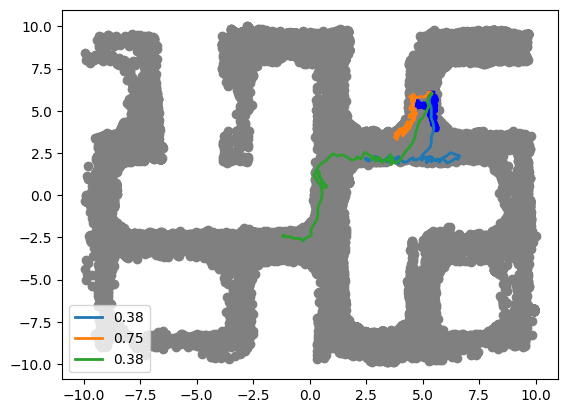

In [ ]:
i = sims_mean.argsort()[54]

plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1], c='gray')

_ = plt.plot(eval_batch['traj_anchors'][i, :, 0].cpu().flatten(), eval_batch['traj_anchors'][i, :, 1].cpu().flatten(), linewidth=5, c='blue', alpha=1)

for j in range(i*NUM_EVAL_SEEDS, (i+1)*NUM_EVAL_SEEDS):
    sim = iou_similarity(torch.tensor(all_produced_trajectories[j]).cpu(), eval_batch['target_trajectories'][i].cpu()) 
    _ = plt.plot(all_produced_trajectories[j, ..., 0].flatten(), all_produced_trajectories[j, ..., 1].flatten(), linewidth=2, alpha=1, label=f'{sim:.2f}')
plt.legend()

In [ ]:
sims_mean.mean(), sims_mean.std()

(0.46072367917027357, 0.2441915037646112)